In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('../data/cleaned/India.csv')

In [4]:
df[df['Category'] == 'Child Vaccinations and Vitamin A Supplementation']['Indicator'].unique()

<StringArray>
['Children age 12-23 months fully vaccinated based on information from either vaccination card or mother's recall (%)',
                      'Children age 12-23 months fully vaccinated based on information from vaccination card only (%)',
                                                                 'Children age 12-23 months who have received BCG (%)',
                                            'Children age 12-23 months who have received 3 doses of polio vaccine (%)',
                                     'Children age 12-23 months who have received 3 doses of penta or DPT vaccine (%)',
                   'Children age 12-23 months who have received the first dose of measlescontaining vaccine (MCV) (%)',
                    'Children age 24-35 months who have received a second dose of measlescontaining vaccine (MCV) (%)',
                                        'Children age 12-23 months who have received 3 doses of rotavirus vaccine (%)',
                          

In [5]:
vacc_df = df[df['Indicator'] == "Children age 12-23 months fully vaccinated based on information from either vaccination card or mother's recall (%)"] 

filter children age 12-23 months... as the primary indicator; assign it to vacc_df

In [6]:
vacc_df.shape

(708, 8)

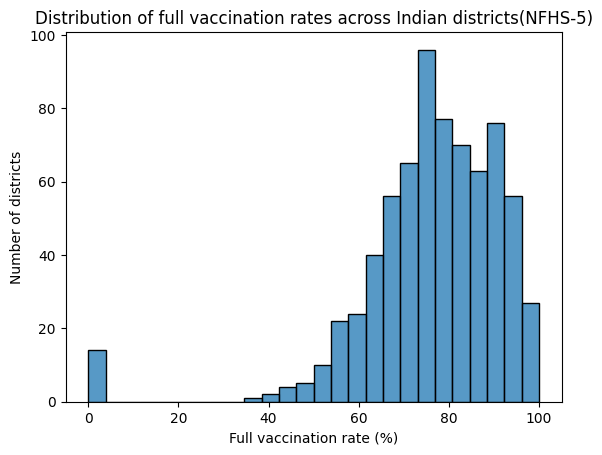

In [7]:
sns.histplot(data=vacc_df, x = "NFHS_5")
plt.title("Distribution of full vaccination rates across Indian districts(NFHS-5)")
plt.xlabel("Full vaccination rate (%)")
plt.ylabel("Number of districts")
plt.savefig("Distribution of full vaccination rates across Indian districts(NFHS-5).png")
plt.show()

Most indian districts have full vaccination rates between 60-95%, with the peak around 75%. But, approximately 14 districts show near-zero vaccination rates, suggesting serious gaps or health failures in those areas; need to investigate

In [8]:
vacc_df[vacc_df["NFHS_5"] < 5]

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
152,Andaman & Nicobar Island,35,North & Middle Andaman,2.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,89.1
14504,Goa,30,South Goa,2.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,89.5
20016,Haryana,6,Sirsa,11.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,75.2
23656,Jammu & Kashmir,1,Data Not Available,99.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,0.0
30000,Kerala,32,Kottayam,10.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,95.2
30416,Kerala,32,Pathanamthitta,12.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,78.0
30624,Kerala,32,Thrissur,7.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,88.3
31976,Madhya Pradesh,23,Bhopal,27.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,62.3
33432,Madhya Pradesh,23,Jabalpur,34.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,67.5
34576,Madhya Pradesh,23,Raisen,29.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,0.0,78.5


Filtered 9 states + 13 districts (except for J&K) with NFHS_5 = 0; NFHS_4 data is consistent; seems to be a data collection issue 

In [9]:
vacc_clean = vacc_df[vacc_df["NFHS_5"] > 0]

In [10]:
zscores = stats.zscore(vacc_clean['NFHS_5'])

In [11]:
vacc_clean[abs(zscores) > 3]

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
7016,Assam,18,Udalguri,27.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,38.3,52.8
41024,Manipur,14,Ukhrul,8.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,39.4,42.4
43936,Nagaland,13,Tuensang,7.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,39.9,43.2


Three Northeast districts — Udalguri (Assam), Ukhrul (Manipur), and Tuensang (Nagaland) — are statistical outliers with vaccination rates below 40%, compared to the national mean of ~76%. All three declined between NFHS-4 and NFHS-5, bucking the national improvement trend.

In [12]:
northeast_vacc = vacc_clean[vacc_clean['State'].isin(['Assam', 'Manipur', 'Nagaland', 'Meghalaya', 'Mizoram', 'Tripura', 'Arunachal Pradesh', 'Sikkim'])]

In [13]:
northeast_vacc.shape

(103, 8)

In [14]:
northeast_state_avg = northeast_vacc.groupby('State')[['NFHS_5', 'NFHS_4']].mean()

In [15]:
northeast_state_avg = northeast_state_avg.reset_index()

In [16]:
northeast_state_avg.columns

Index(['State', 'NFHS_5', 'NFHS_4'], dtype='str')

In [17]:
northeast_vacc_melted = pd.melt(northeast_state_avg, id_vars = ['State'], value_vars = ['NFHS_5', 'NFHS_4'])

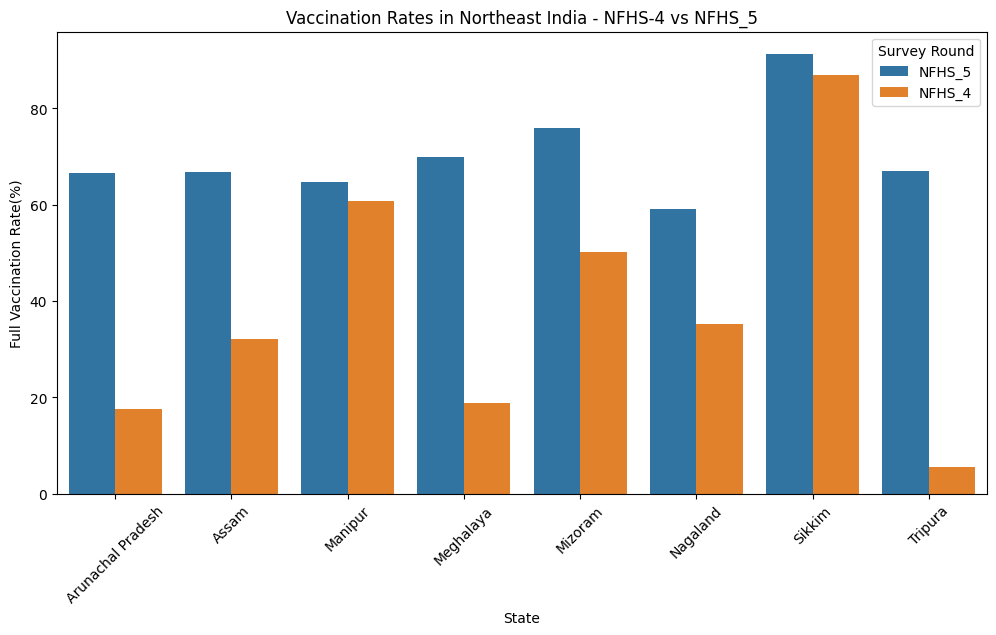

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(data=northeast_vacc_melted, x='State', y='value', hue='variable')
plt.title("Vaccination Rates in Northeast India - NFHS-4 vs NFHS_5")
plt.xlabel('State')
plt.ylabel('Full Vaccination Rate(%)')
plt.xticks(rotation=45)
plt.legend(title="Survey Round")
plt.savefig('../outputs/northeast_vacc_comparison.png', bbox_inches='tight')
plt.show()

The chart above compares full vaccination rates across the 8 different states of the northeast between NFHS-4(2015-2016) & NFHS-5(2019-2021).

Key findings
- Arunachal Pradesh and Tripura made the most significant improvements, from under 20% to over 60%
- Sikkim remains the highest performer, with above 80% for both NFHS-4 and NFHS-5
- Manipur showed the smallest improvement, with no major change for both surveys
- Nagaland remains the lowest performer, under 40% in NFHS-4 and 59% in NFHS-5

All eight states showed improvement, bucking concerns about regional stagnation — however Manipur and Nagaland remain significantly below the national average of 76.8%.

In [19]:
df[df['Category'] == 'Maternal and Child Health']['Indicator'].unique()

<StringArray>
[                                                              'Mothers who had an antenatal checkup in the first trimester (%)',
                                                                          'Mothers who had at least 4 antenatal care visits (%)',
                                                           'Mothers whose last birth was protected against neonatal tetanus (%)',
                                         'Mothers who consumed iron folic acid for 100 days or more when they were pregnant (%)',
                                         'Mothers who consumed iron folic acid for 180 days or more when they were pregnant (%)',
                             'Registered pregnancies for which the mother received a Mother and Child Protection (MCP) card (%)',
  'Mothers who received postnatal care from a doctor/nurse/LHV/ANM/midwife/other health personnel within 2 days of delivery (%)',
                                               'Average out-of-pocket expend

In [20]:
matr_df = df[df['Indicator'] == 'Mothers who had at least 4 antenatal care visits (%)']

In [21]:
matr_df.shape

(708, 8)

In [22]:
matr_df[matr_df["NFHS_5"] < 5]

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
23640,Jammu & Kashmir,1,Data Not Available,99.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,0.0,0.0
43920,Nagaland,13,Tuensang,7.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,4.4,4.6


In [23]:
matr_clean = matr_df[matr_df['State'] != 'Jammu & Kashmir']

In [24]:
zscores = stats.zscore(matr_clean['NFHS_5'])
matr_clean[abs(zscores) > 3]

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4


Zscore outlier check found no districts beyond 3 standard deviations 
for antenatal care visits, suggesting more uniform distribution 
compared to vaccination rates.

In [25]:
northeast_matr = matr_clean[matr_clean['State'].isin(['Assam', 'Manipur', 'Nagaland', 'Meghalaya', 'Mizoram', 'Tripura', 'Arunachal Pradesh', 'Sikkim'])]

In [26]:
northeast_matr.shape

(104, 8)

In [27]:
northeast_avg = northeast_matr.groupby('State')[['NFHS_5', 'NFHS_4']].mean()

In [28]:
northeast_avg = northeast_avg.reset_index()

In [29]:
northeast_avg.columns

Index(['State', 'NFHS_5', 'NFHS_4'], dtype='str')

In [30]:
northeast_matr_melted = pd.melt(northeast_avg, id_vars = ['State'], value_vars = ['NFHS_5', 'NFHS_4'])

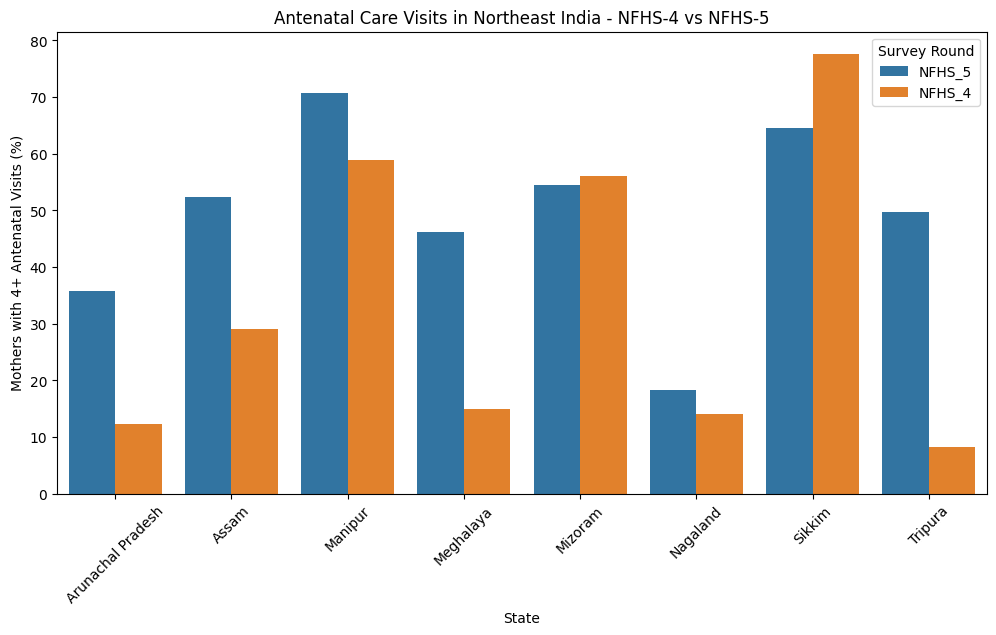

In [31]:
plt.figure(figsize=(12,6))
sns.barplot(data=northeast_matr_melted, x='State', y='value', hue='variable')
plt.title("Antenatal Care Visits in Northeast India - NFHS-4 vs NFHS-5")
plt.xlabel('State')
plt.ylabel('Mothers with 4+ Antenatal Visits (%)')
plt.xticks(rotation=45)
plt.legend(title="Survey Round")
plt.savefig('../outputs/northeast_matr_comparison.png', bbox_inches='tight')
plt.show()

The chart compares antenatal care visits in Northeast India between NFHS-4(2015-16) & NFHS-5(2019-2021).

Key findings
- Sikkim declined from 78% in NFHS-4 to 65% in NFHS-5
- Tripura, Meghalaya, Assam and Arunachal made major improvements, less than 15% in NFHS-4 to 35-45% in NFHS-5
- Manipur remains the highest in NFHS-5 at 70% 
- Mizoram declined slightly from 56% to 55%
- Nagaland remains the lowest, below 20% in both surveys

Notably, Manipur leads the Northeast in antenatal care despite 
performing poorly on vaccination rates, suggesting maternal 
healthcare infrastructure is stronger than childhood immunization delivery.

In [32]:
df[df['Category'] == 'Child Feeding Practices and Nutritional Status of Children']['Indicator'].unique() 

<StringArray>
[           'Children under age 3 years breastfed within one hour of birth (%)',
                        'Children under age 6 months exclusively breastfed (%)',
 'Children age 6-8 months receiving solid or semisolid food and breastmilk (%)',
        'Breastfeeding children age 6-23 months receiving an adequate diet (%)',
     'Nonbreastfeeding children age 6-23 months receiving an adequate diet (%)',
                'Total children age 6-23 months receiving an adequate diet (%)',
                  'Children under 5 years who are stunted (height for age) (%)',
                'Children under 5 years who are wasted (weight for height) (%)',
       'Children under 5 years who are severely wasted (weight for height) (%)',
              'Children under 5 years who are underweight (weight for age) (%)',
          'Children under 5 years who are overweight (weight fo rheight)20 (%)']
Length: 11, dtype: str

In [33]:
mal_df = df[df['Indicator'] == 'Children under 5 years who are stunted (height for age) (%)']

In [34]:
mal_df.shape

(708, 8)

In [35]:
mal_df[mal_df['NFHS_5'] < 5]

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
23680,Jammu & Kashmir,1,Data Not Available,99.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,0.0,0.0


In [36]:
mal_clean = mal_df[mal_df['State'] != 'Jammu & Kashmir']

In [37]:
zscores = stats.zscore(mal_clean['NFHS_5'])
mal_clean[abs(zscores) > 3]

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
25552,Jharkhand,20,Pashchimi Singhbhum,23.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,60.6,59.4


Data suggests Jharkhand is India's most malnutritionally challenges states; 60.6% children under 5 are stunted

In [38]:
northeast_mal = mal_clean[mal_clean['State'].isin(['Assam', 'Manipur', 'Nagaland', 'Meghalaya', 'Mizoram', 'Tripura', 'Arunachal Pradesh', 'Sikkim'])]

In [39]:
northeast_mal.shape

(104, 8)

In [40]:
northeast_av = northeast_mal.groupby('State')[['NFHS_4', 'NFHS_5']].mean()

In [41]:
northeast_av = northeast_av.reset_index()

In [42]:
northeast_av.columns

Index(['State', 'NFHS_4', 'NFHS_5'], dtype='str')

In [43]:
northeast_mal_melted = pd.melt(northeast_av, id_vars = ['State'], value_vars = ['NFHS_5', 'NFHS_4'])

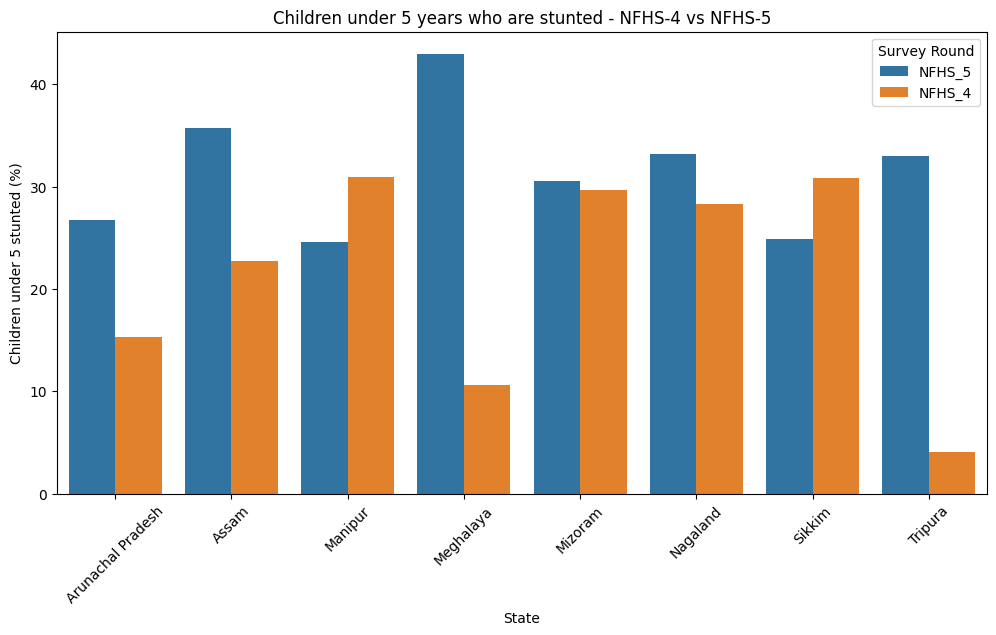

In [44]:
plt.figure(figsize=(12,6))
sns.barplot(data=northeast_mal_melted, x='State', y='value', hue='variable')
plt.title("Children under 5 years who are stunted - NFHS-4 vs NFHS-5")
plt.xlabel('State')
plt.ylabel('Children under 5 stunted (%)')
plt.xticks(rotation=45)
plt.legend(title="Survey Round")
plt.savefig('../outputs/northeast_mal_comparison.png', bbox_inches='tight')
plt.show()

The chart above shows the percentage of children under 5 years who are 
stunted (height for age) across eight Northeast states between 
NFHS-4 (2015-16) and NFHS-5 (2019-21).

Key findings:
- Every Northeast state except Manipur and Sikkim saw stunting rates worsen
- Meghalaya showed the most alarming increase, jumping from 10.7% to 43.3%
- Tripura nearly doubled from 3.9% to 33.2%
- Manipur was the only major improver, declining from 31.1% to 24.6%
- Sikkim also showed slight improvement, from 31.1% to 25%

Context:
The worsening across most states likely reflects disruption to 
nutrition programs like ICDS during the COVID-19 pandemic, which 
overlapped with the NFHS-5 data collection period (2019-21).
Manipur's improvement despite regional trends suggests stronger 
nutrition program delivery at the district level.

In [45]:
vacc_clean[vacc_clean['State'] == 'Manipur']['NFHS_5'].mean()

np.float64(64.81111111111112)

In [46]:
vacc_clean['NFHS_5'].mean()

np.float64(77.71008645533142)

In [47]:
matr_clean[matr_clean['State'] == 'Manipur']['NFHS_5'].mean()

np.float64(70.64444444444445)

In [48]:
matr_clean['NFHS_5'].mean()

np.float64(59.89898107714703)

In [49]:
mal_clean[mal_clean['State'] == 'Manipur']['NFHS_5'].mean()

np.float64(24.62222222222222)

In [50]:
mal_clean['NFHS_5'].mean()

np.float64(33.734934497816596)

Manipur built strong facility based maternal care but lost the community outreach infrastructure that drove vaccination.

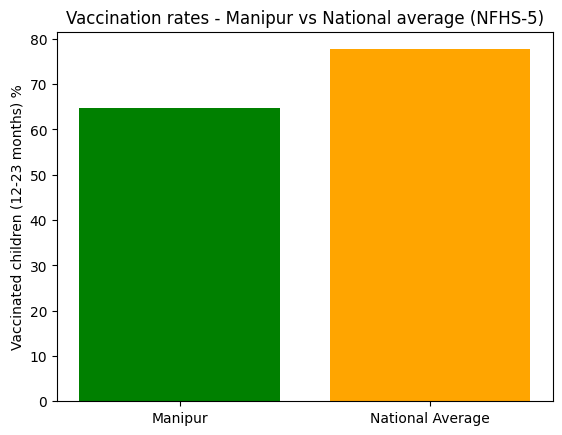

In [51]:
categories = ['Manipur', 'National Average']
values = [64.8, 77.7]
plt.bar(categories, values, color = ['Green', 'Orange'])
plt.title("Vaccination rates - Manipur vs National average (NFHS-5)")
plt.ylabel("Vaccinated children (12-23 months) %")
plt.savefig('../outputs/manipur_vacc_comp.png', bbox_inches="tight")


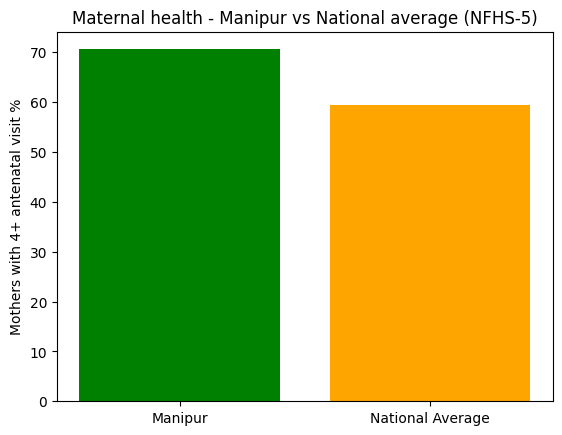

In [52]:
categories = ['Manipur', 'National Average']
values = [70.6, 59.5]
plt.bar(categories, values, color = ['Green', 'Orange'])
plt.title("Maternal health - Manipur vs National average (NFHS-5)")
plt.ylabel("Mothers with 4+ antenatal visit %")
plt.savefig('../outputs/manipur_matr_comp.png', bbox_inches="tight")

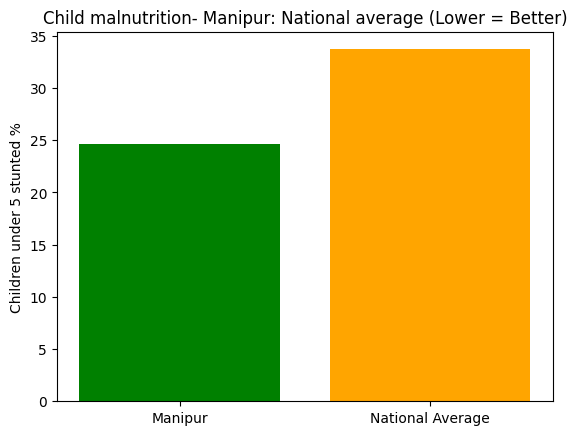

In [53]:
categories = ['Manipur', 'National Average']
values = [24.6, 33.7]
plt.bar(categories, values, color = ['Green', 'Orange'])
plt.title("Child malnutrition- Manipur: National average (Lower = Better)")
plt.ylabel("Children under 5 stunted %")
plt.savefig('../outputs/manipur_mal_comp.png', bbox_inches="tight")

In [54]:
vacc_clean.nlargest(n=10, columns = 'NFHS_5')

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
14088,Dadra & Nagar Haveli,26,Dadra & Nagar Haveli,1.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,100.0,43.2
20328,Himachal Pradesh,2,Bilaspur,8.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,100.0,58.3
20432,Himachal Pradesh,2,Chamba,1.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,100.0,64.6
22304,Jammu & Kashmir,1,Kathua,7.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,100.0,82.5
28752,Karnataka,29,Ramanagara,30.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,100.0,58.8
46120,Odisha,21,Debagarh,4.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,100.0,68.4
51008,Punjab,3,Shahid Bhagat Singh Nagar,5.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,100.0,86.1
57560,Tamil Nadu,33,Thoothukkudi,26.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,100.0,47.7
22512,Jammu & Kashmir,1,Kulgam,15.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,98.1,83.0
47368,Odisha,21,Koraput,29.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,98.0,67.1


In [55]:
vacc_clean.nsmallest(n=10, columns = 'NFHS_5')

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
7016,Assam,18,Udalguri,27.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,38.3,52.8
41024,Manipur,14,Ukhrul,8.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,39.4,42.4
43936,Nagaland,13,Tuensang,7.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,39.9,43.2
43208,Nagaland,13,Kiphire,9.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,42.8,36.0
44040,Nagaland,13,Wokha,4.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,42.8,22.6
15024,Gujarat,24,Banaskantha,2.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,43.5,35.3
66192,Uttar Pradesh,9,Jhansi,35.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,44.5,62.7
41440,Meghalaya,17,North Garo Hills,NaN,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,47.5,0.0
7120,Assam,18,West Karbi Anglong,NaN,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,47.9,0.0
62136,Tripura,16,South Tripura,2.0,Child Vaccinations and Vitamin A Supplementation,Children age 12-23 months fully vaccinated bas...,48.5,0.0


In [56]:
matr_clean.nlargest(n=10, columns = 'NFHS_5')

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
57232,Tamil Nadu,33,Theni,23.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,98.7,75.9
56400,Tamil Nadu,33,Namakkal,8.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,97.8,81.6
57960,Tamil Nadu,33,Tiruvannamalai,5.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,97.7,83.5
55568,Tamil Nadu,33,Dindigul,11.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,96.2,88.8
14488,Goa,30,South Goa,2.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,96.0,81.5
55984,Tamil Nadu,33,Karur,12.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,95.7,82.9
45480,Odisha,21,Balangir,24.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,95.4,76.5
58064,Tamil Nadu,33,Vellore,4.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,95.4,92.5
47976,Odisha,21,Puri,18.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,94.9,81.8
58168,Tamil Nadu,33,Viluppuram,6.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,94.9,79.5


In [57]:
matr_clean.nsmallest(n=10, columns = 'NFHS_5')

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
43920,Nagaland,13,Tuensang,7.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,4.4,4.6
43192,Nagaland,13,Kiphire,9.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,5.8,2.0
43816,Nagaland,13,Phek,6.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,9.5,6.6
43608,Nagaland,13,Mon,1.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,9.7,3.6
10016,Bihar,10,Purnia,9.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,11.1,12.2
44128,Nagaland,13,Zunheboto,3.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,11.2,5.9
10224,Bihar,10,Saharsa,12.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,11.7,10.1
43712,Nagaland,13,Peren,11.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,14.5,13.1
8664,Bihar,10,Katihar,10.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,15.3,8.9
43400,Nagaland,13,Longleng,8.0,Maternal and Child Health,Mothers who had at least 4 antenatal care visi...,15.4,1.5


In [58]:
mal_clean.nlargest(n=10, columns = 'NFHS_5')

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
25552,Jharkhand,20,Pashchimi Singhbhum,23.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,60.6,59.4
42192,Meghalaya,17,West Khasi Hills,4.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,59.0,0.0
29296,Karnataka,29,Yadgir,26.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,57.6,55.5
15568,Gujarat,24,Dahod,18.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,55.3,44.4
10784,Bihar,10,Sitamarhi,4.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,54.2,57.3
11824,Chhattisgarh,22,Bijapur,18.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,53.8,48.2
10576,Bihar,10,Sheikhpura,26.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,53.6,46.4
63200,Uttar Pradesh,9,Bahraich,49.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,52.1,65.1
64032,Uttar Pradesh,9,Budaun,18.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,51.8,0.0
69024,Uttar Pradesh,9,Sambhal,NaN,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,51.6,0.0


In [59]:
mal_clean.nsmallest(n=10, columns = 'NFHS_5')

,State,ST_CEN_CD,District,DT_CEN_CD,Category,Indicator,NFHS_5,NFHS_4
46560,Odisha,21,Jagatsinghapur,11.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,13.2,19.5
48016,Odisha,21,Puri,18.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,13.8,16.1
2672,Arunachal Pradesh,12,Lower Dibang Valley,14.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,14.3,22.3
50720,Punjab,3,Rupnagar,17.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,15.1,19.0
29920,Kerala,32,Kollam,13.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,15.5,14.4
40216,Manipur,14,Bishnupur,4.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,15.5,24.7
18792,Haryana,6,Jhajjar,15.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,15.6,22.3
28776,Karnataka,29,Ramanagara,30.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,15.6,22.0
40632,Manipur,14,Imphal West,6.0,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,15.6,21.0
2568,Arunachal Pradesh,12,Longding,NaN,Child Feeding Practices and Nutritional Status...,Children under 5 years who are stunted (height...,15.8,0.0


In [60]:
mal_state_avg = mal_clean.groupby('State')['NFHS_5'].mean()

In [61]:
mal_state_avg.sort_values(ascending=False).head(10)

State
Meghalaya               42.981818
Bihar                   42.589474
Dadra & Nagar Haveli    42.400000
Jharkhand               40.187500
Uttar Pradesh           39.634667
Gujarat                 38.660606
Assam                   35.696970
Chhattisgarh            35.674074
Madhya Pradesh          35.374510
Maharashtra             35.108333
Name: NFHS_5, dtype: float64

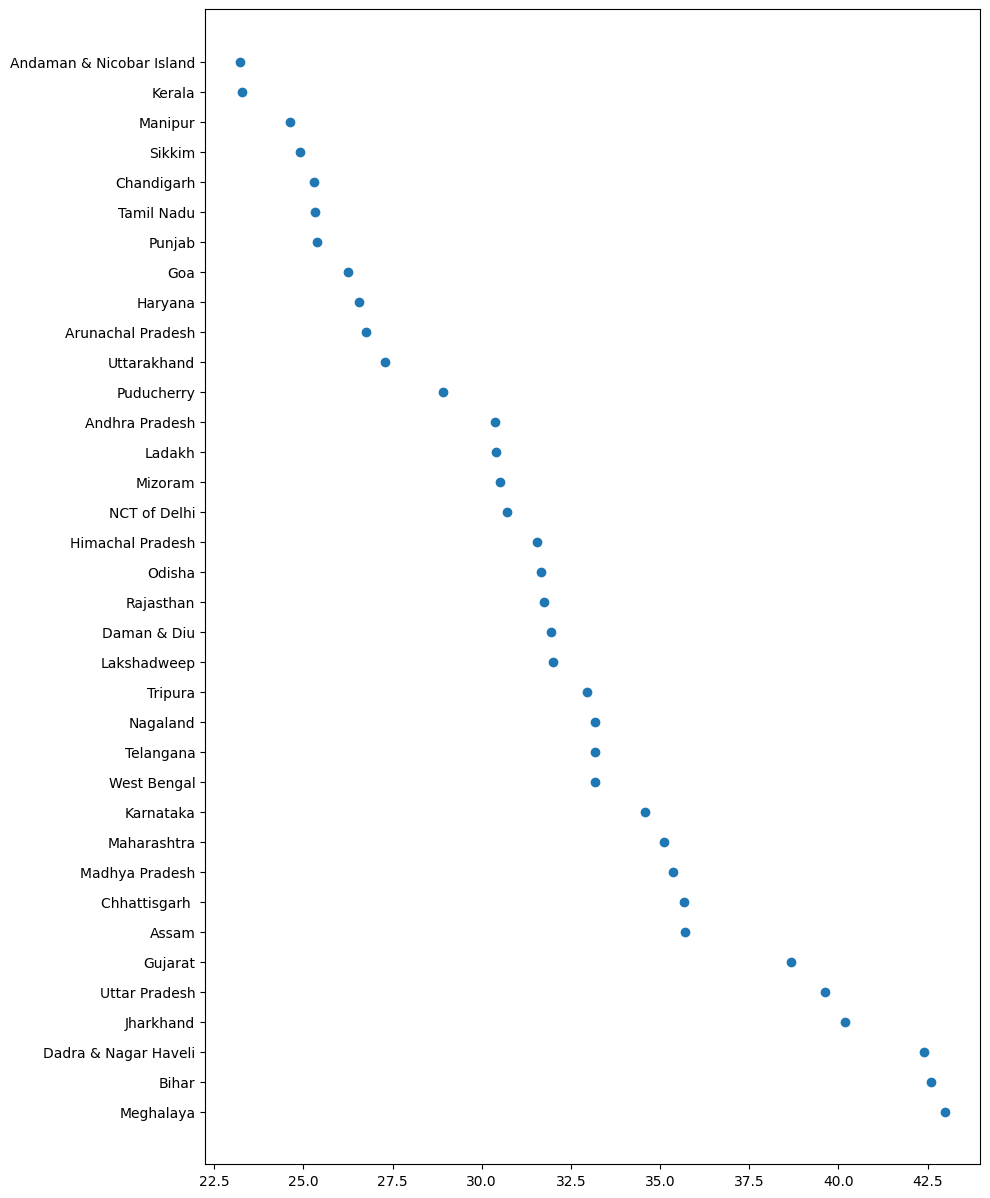

In [62]:
sorted_mal = mal_state_avg.sort_values(ascending=False)
values = sorted_mal.values
labels = sorted_mal.index
plt.figure(figsize=(10,15))
plt.plot(values, labels, 'o')
plt.savefig('../outputs/dot_chart_malnutrtion.png', bbox_inches="tight")

In [63]:
vacc_merge = vacc_clean[['NFHS_5', 'District', 'DT_CEN_CD', 'State']].rename(columns={'NFHS_5': 'vaccination rates'})

In [64]:
matr_merge = matr_clean[['NFHS_5', 'District', 'DT_CEN_CD', 'State']].rename(columns={'NFHS_5': 'antenatal care'})

In [65]:
mal_merge = mal_clean[['NFHS_5', 'District', 'DT_CEN_CD', 'State']].rename(columns={'NFHS_5': 'child malnutrition'})

In [66]:
temp_df = pd.merge(vacc_merge, matr_merge, on=['State','District'], how='inner')

In [67]:
health_df = pd.merge(temp_df, mal_merge, on=['State','District'], how='inner')

In [68]:
health_df = health_df.drop(columns=['DT_CEN_CD_x', 'DT_CEN_CD_y', 'DT_CEN_CD'])

In [70]:
health_df.to_csv('../data/cleaned/health_merged.csv', index=False)